# Modelingthe data we have processed after the EDA

The feature engineering performed above has been exported to `data/processed/qrt_ready.csv` (105,414 rows × 70 columns) and can be reloaded directly without rerunning the preprocessing steps.

The pipeline below mirrors exactly what the dashboard does under the hood:

1. **Load** `data/processed/qrt_ready.csv` — the preprocessed panel data with all engineered features ready to use
2. **Select features** — pick any subset from the 68 available features; edit the `FEATURES` list to experiment
3. **Build & prepare the `Dataset`** — handles train/val/test splitting, scaling, and imputation automatically
4. **Tune with Optuna → `ModelTrainer`** — runs `N_TRIALS` Optuna trials across RF / XGBoost / LightGBM / LR and returns the best model + hyperparameters
5. **Evaluate** — accuracy, ROC-AUC, classification report on the held-out test set
6. **Visualize** — confusion matrix + feature importances (identical to the dashboard output)

In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from models.preparing import Dataset
from models.modeling import ModelTrainer
from models.visualizing import ModelVisualizer

# ── Chargement ───────────────────────────────────────────────────────────────
qrt = pd.read_csv('../data/processed/qrt_ready.csv')
print(f"Données chargées : {qrt.shape[0]:,} lignes × {qrt.shape[1]} colonnes")
qrt.head(3)

Données chargées : 105,414 lignes × 70 colonnes


,RET_1,RET_2,RET_3,RET_4,RET_5,RET_6,RET_7,RET_8,RET_9,RET_10,...,SVOL_SHORT,CONVICTION,CS_RANK_RET1,CS_RANK_VOL5,CS_GROUP_MEAN_RET1,CS_GROUP_STD_RET1,CS_GROUP_RANK_RET1,CS_GROUP_RANK_VOL5,target_clf,date
0,0.003944,-0.000178,0.001013,0.001514,-0.009067,0.002864,-0.009116,0.003312,0.001350,-0.009898,...,0.669370,-0.000865,0.989130,0.927536,-0.000199,0.001452,0.985714,0.971429,1,2020-01-02
1,0.002323,0.000670,0.001383,-0.003427,0.000577,0.003323,0.003926,0.002878,-0.000259,-0.000376,...,-2.542246,-0.001670,0.960145,0.576087,-0.000036,0.001162,1.000000,0.878788,1,2020-01-02
2,-0.000238,-0.002696,-0.003926,-0.000569,-0.002528,0.004384,-0.011090,-0.002392,0.006396,-0.006482,...,2.156060,-0.000064,0.460145,0.315217,-0.000199,0.001452,0.528571,0.485714,1,2020-01-02


In [2]:
# ── Features 
FEATURES = [
    # Momentum court terme
    "RET_1", "RET_2", "RET_3", "RET_5",
    # Momentum lissé
    "MOM_3", "MOM_5", "MOM_vs_MEAN",
    # Volatilité
    "VOL_5", "VOL_20", "VOL_RATIO", "SHARPE_5",
    # Volume
    "SVOL_SHORT", "CONVICTION",
    # Cross-sectional
    "CS_RANK_RET1", "CS_RANK_VOL5",
    "CS_GROUP_MEAN_RET1", "CS_GROUP_RANK_RET1",
    # Performance agrégée
    "AVERAGE_PERF_3", "AVERAGE_PERF_5",
]

TARGET      = "target_clf"
TIMESTAMP   = "date"


print(f"{len(FEATURES)} features sélectionnées")
print(FEATURES)

19 features sélectionnées
['RET_1', 'RET_2', 'RET_3', 'RET_5', 'MOM_3', 'MOM_5', 'MOM_vs_MEAN', 'VOL_5', 'VOL_20', 'VOL_RATIO', 'SHARPE_5', 'SVOL_SHORT', 'CONVICTION', 'CS_RANK_RET1', 'CS_RANK_VOL5', 'CS_GROUP_MEAN_RET1', 'CS_GROUP_RANK_RET1', 'AVERAGE_PERF_3', 'AVERAGE_PERF_5']


In [3]:
# ── Dataset + préparation ─────────────────────────────────────────────────────
TEST_SIZE   = 0.15
VAL_SIZE    = 0
dataset_qrt = Dataset(
    data=qrt,
    target=TARGET,
    features=FEATURES,
    timestamp_col=TIMESTAMP,
)

dataset_qrt.prepare_dataset(
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    shuffle=False,          # time series → pas de shuffle
    scale_numeric=True,
    use_knn_for_numeric=False,
)

splits = dataset_qrt.splits
print(f"Train : {splits.X_train.shape}  |  Test : {splits.X_test.shape}")
print(f"Target distribution (train) : {pd.Series(splits.y_train).value_counts().to_dict()}")

Train : (89601, 19)  |  Test : (15813, 19)
Target distribution (train) : {1: 45859, 0: 43742}


In [4]:
# ── ModelTrainer (Optuna) ─────────────────────────────────────────────────────
IS_CLF      = True      # classification (up/down)
N_TRIALS    = 2        # nombre de trials Optuna


trainer_qrt = ModelTrainer(
    dataset=dataset_qrt,
    is_classification=IS_CLF,
    n_trials=N_TRIALS,
    shuffle=False,
)

print(f"\nMeilleur modèle : {type(trainer_qrt.model).__name__}")
print(f"Meilleurs params : {trainer_qrt.best_params}")

Starting model optimization with 2 trials...
Optimization complete
  Best model : LogisticRegression
  Best params: {'penalty': 'l2', 'C': 0.006614600424674984}
Top 20 Coefficients (by abs value):
  num__MOM_vs_MEAN: 0.040748
  num__CS_GROUP_MEAN_RET1: 0.040073
  num__CS_RANK_VOL5: 0.033679
  num__RET_2: -0.028695
  num__RET_5: 0.027867
  num__SVOL_SHORT: -0.027766
  num__RET_1: 0.025819
  num__SHARPE_5: 0.024113
  num__MOM_5: -0.023225
  num__AVERAGE_PERF_5: -0.023225
  num__CS_GROUP_RANK_RET1: 0.022395
  num__VOL_20: 0.015240
  num__VOL_RATIO: -0.014055
  num__CONVICTION: -0.006383
  num__RET_3: 0.005527
  num__CS_RANK_RET1: -0.003243
  num__MOM_3: 0.001037
  num__AVERAGE_PERF_3: 0.001037
  num__VOL_5: -0.000765
Classification Report (Train):
              precision    recall  f1-score   support

           0       0.52      0.38      0.44     43742
           1       0.53      0.66      0.59     45859

    accuracy                           0.52     89601
   macro avg       0.52    

In [5]:
# ── Métriques sur le test set ─────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_test  = dataset_qrt.splits.y_test
y_pred  = trainer_qrt.y_test_pred
y_proba = trainer_qrt.model.predict_proba(dataset_qrt.splits.X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))

Accuracy : 0.5293
ROC-AUC  : 0.5352

              precision    recall  f1-score   support

    Down (0)       0.55      0.39      0.46      7989
      Up (1)       0.52      0.67      0.58      7824

    accuracy                           0.53     15813
   macro avg       0.53      0.53      0.52     15813
weighted avg       0.53      0.53      0.52     15813



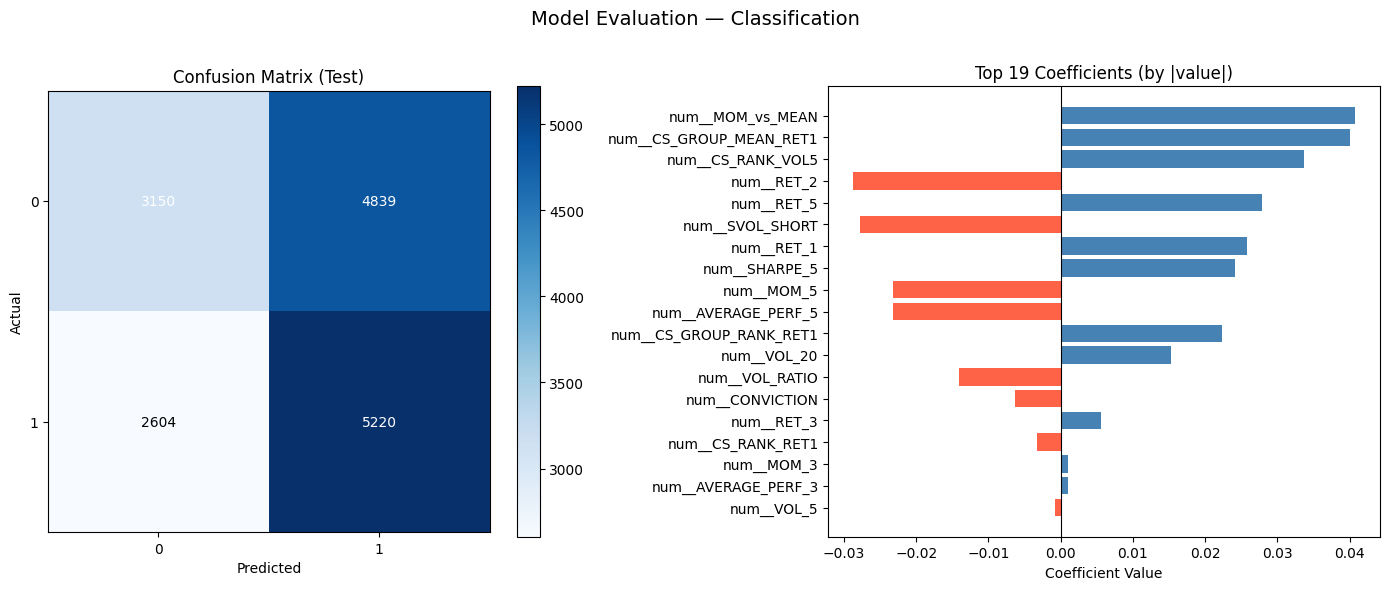

<Figure size 640x480 with 0 Axes>

In [6]:
# ── Visualisations (même que le dashboard) ───────────────────────────────────
import matplotlib.pyplot as plt
%matplotlib inline

viz_qrt = ModelVisualizer(trainer_qrt)
viz_qrt.run_all()
plt.tight_layout()
plt.show()